# La stratégie du 05b, adaptée — portefeuille d'entrée + trades O/A/T

**Même stratégie** que la Partie II des slides données (le 05b : moteur « membre = fonds »,
sélection point-in-time au 31/12/Y, top-4 en parts) — avec **deux changements de données** :

1. chaque membre démarre de son **portefeuille d'entrée** (photo H/C, Schedule A) au lieu de zéro ;
2. le flux de trades = **PTR ∪ trades que seuls les rapports O/A/T contiennent** — chaque trade porte
   sa `provenance ∈ {ptr, oat}`.

Quatre runs isolent chaque effet : **A** = 05b tel quel (témoin, reproduit à l'identique) ·
**B** = A + h₀ · **C** = A + flux O/A/T · **D** = les deux (**la stratégie adaptée**).

Périmètre : les ajouts sont House (le Sénat n'a pas d'ingestion non-P) ; réglages du 05b inchangés.
Plan : §0 données prouvées · §1 moteur 05b (copie exacte) · §2 les deux ajouts · §3 les 4 runs ·
§4 la stratégie rejouée · §5 lecture.

## §0 — Données : trois sources, chacune prouvée

Tables v1-house (sha256 ≡ `MANIFEST.json`), table clean S1/S2 (celle du 05b), prix
(`prices_v2` du 05b — jamais modifié — et `prices_holdings_v1`, cache séparé pour les tickers de photos).

In [1]:
import pandas as pd, numpy as np, hashlib, json, os, glob, re
import matplotlib.pyplot as plt

J     = "/Users/lemairealice/Downloads/Jupiter"
BASE  = os.path.join(J, "00. S3S4 en cours")
V1T   = os.path.join(J, "01_v1_house", "cache", "tables")
CLEAN = os.path.join(J, "00_S1S2_donnees", "data", "clean", "transactions_backtest_2014_2026.csv")
MAN   = json.load(open(os.path.join(J, "01_v1_house", "cache", "MANIFEST.json")))

for _f in ["11_holdings_complets.csv", "15_portefeuille_entree.csv", "16_flux_oat_net.csv"]:
    _h = hashlib.sha256(open(os.path.join(V1T, _f), "rb").read()).hexdigest()
    assert _h == MAN["sha_tables"][_f], f"sha divergent : {_f}"
print("3 tables v1-house conformes au MANIFEST (sha256)")

3 tables v1-house conformes au MANIFEST (sha256)


**Chargements.** `15` = les 284 photos d'entrée datées (252 H + 32 C) ; `11` = les holdings ligne à
ligne (Schedule A, fourchettes de valeur) ; `16` = les 26 115 trades O/A/T **sans écho PTR à ±365 j**
(dédoublonnés par le notebook V1, cellule É7).

In [2]:
e15 = pd.read_csv(os.path.join(V1T, "15_portefeuille_entree.csv"), parse_dates=["filing_date"])
h11 = pd.read_csv(os.path.join(V1T, "11_holdings_complets.csv"), low_memory=False,
                  usecols=["doc_id", "bioguide", "ticker", "value_lo", "value_hi", "conteneur_nu"],
                  parse_dates=False)
f16 = pd.read_csv(os.path.join(V1T, "16_flux_oat_net.csv"), low_memory=False,
                  parse_dates=["transaction_date", "disclosure_date"])
print(f"photos d'entrée : {len(e15)} ({dict(e15['type_photo'].value_counts())}) | "
      f"holdings : {len(h11):,} | trades O/A/T nets : {len(f16):,}")

photos d'entrée : 284 ({'H': np.int64(252), 'C': np.int64(32)}) | holdings : 420,916 | trades O/A/T nets : 26,115


In [3]:
# Aperçu des trois tables (règle : toute table créée montre sa tête)
for _nom, _t in [("15_portefeuille_entree", e15), ("11_holdings_complets", h11),
                 ("16_flux_oat_net", f16)]:
    print(f"{_nom} — {_t.shape[0]:,} lignes × {_t.shape[1]} colonnes")
    display(_t.head(3))

15_portefeuille_entree — 284 lignes × 7 colonnes


,bioguide,doc_id,type_photo,filing_date,n_tickers,delta_jours_mandat,garde_fous_ok
0,A000148,10040680,H,2021-07-29,27,NaN,True
1,A000373,10005854,H,2015-05-14,83,NaN,True
2,A000375,10009542,C,2016-02-13,2,325.0,True


11_holdings_complets — 420,916 lignes × 6 colonnes


,ticker,value_lo,value_hi,doc_id,conteneur_nu,bioguide
0,NaN,15001,50000.0,10023848,False,A000374
1,NaN,1000001,5000000.0,10023848,False,A000374
2,NaN,50001,100000.0,10023848,False,A000374


16_flux_oat_net — 26,115 lignes × 28 colonnes


,doc_id,provenance,filing_type,annee_index,bioguide,declarant_name,state_district,transaction_date,transaction_date_brute,disclosure_date,...,amount_mid,amount_mid_conventionnel,amount_reconstruit,amount_exact,cle_naturelle,occurrence_index,n_docs_vus,source,sens,echo_ptr
0,10004256,fd_T,T,2014,C001046,Eric Ivan Cantor,VA07,2014-01-16,01/16/2014,2014-09-15,...,8000.5,8000.5,False,False,"C001046|01/16/2014|LEO|P|$1,001 - $15,000|SELF",0,1,instantane_seul,P,False
1,10004256,fd_T,T,2014,C001046,Eric Ivan Cantor,VA07,2014-01-31,01/31/2014,2014-09-15,...,75000.5,75000.5,False,False,"C001046|01/31/2014|LEO|S|$50,001 - $100,000|SELF",0,1,instantane_seul,S,False
2,10004256,fd_T,T,2014,C001046,Eric Ivan Cantor,VA07,2014-01-16,01/16/2014,2014-09-15,...,8000.5,8000.5,False,False,"C001046|01/16/2014|MOO|P|$1,001 - $15,000|SELF",0,1,instantane_seul,P,False


**Tickers.** Map m : `ticker` → `ticker_yahoo` **reconstruite** depuis la table clean
(zéro constante héritée) ; défaut m(t) = t avec « . » → « - ».

In [4]:
cl_map = pd.read_csv(CLEAN, usecols=["ticker", "ticker_yahoo", "amount_range", "amount_midpoint"],
                     low_memory=False)
_paires = cl_map[["ticker", "ticker_yahoo"]].dropna().drop_duplicates()
assert (_paires.groupby("ticker")["ticker_yahoo"].nunique() <= 1).all(), "map ambiguë"
MAP_YAHOO = dict(zip(_paires["ticker"], _paires["ticker_yahoo"]))
def to_yahoo(t):
    t = str(t)
    return MAP_YAHOO.get(t, t.replace(".", "-"))
print(f"map tickers : {len(MAP_YAHOO)} paires, "
      f"{sum(1 for k, v in MAP_YAHOO.items() if k != v)} renommages, 0 conflit")
display(_paires[_paires["ticker"] != _paires["ticker_yahoo"]].head(3))

map tickers : 4653 paires, 52 renommages, 0 conflit


,ticker,ticker_yahoo
217,CTL,LUMN
255,DISCA,WBD
260,FB,META


**Fourchettes.** Un montant déclaré est une fourchette [v̲, v̄] ; on prend ṽ = (v̲+v̄)/2.
Preuve : les milieux v1 ≡ `amount_midpoint` de la table clean sur toutes les fourchettes communes.

In [5]:
_g_clean = (cl_map.dropna(subset=["amount_range", "amount_midpoint"])
            .groupby("amount_range")["amount_midpoint"].first())
_v1_mid = (f16.assign(mid=(f16["amount_lo"] + f16["amount_hi"]) / 2)
           .groupby("amount_range")["mid"].first())
_commun = _g_clean.index.intersection(_v1_mid.index)
assert (_g_clean.loc[_commun] - _v1_mid.loc[_commun]).abs().max() == 0
print(f"fourchettes : {len(_commun)} amount_range communs, écart max des milieux = 0 ✅")
display(pd.DataFrame({"midpoint_clean": _g_clean.loc[_commun], "mid_v1": _v1_mid.loc[_commun]}).head(4))

fourchettes : 12 amount_range communs, écart max des milieux = 0 ✅


,midpoint_clean,mid_v1
amount_range,,
"$1,000,001 - $5,000,000",3000000.5,3000000.5
"$1,001 - $15,000",8000.5,8000.5
"$100,001 - $250,000",175000.5,175000.5
$121,121.0,121.0


In [6]:
# Garde-fou : prices_v2 est snapshoté ici et re-asserté en toute fin de notebook.
PRICES_V2 = os.path.join(BASE, "cache", "prices_v2")
_SNAP_PV2 = sorted(os.listdir(PRICES_V2))
_perdus = sorted(set(e15["doc_id"]) - set(h11["doc_id"]))
assert _perdus == [10041638]
print(f"snapshot prices_v2 : {len(_SNAP_PV2)} fichiers | 1 photo d'entrée sans holdings, journalisée : {_perdus}")

snapshot prices_v2 : 3351 fichiers | 1 photo d'entrée sans holdings, journalisée : [10041638]


## §1 — Le moteur du 05b, recopié à l'identique

Pattern du 07/09 : cellules recopiées **verbatim**, jamais redéfinies. Elles fournissent `df`
(118 029 trades PTR avec prix), `prices`/`cal`/`r_spy`, `member_shares`, `daily_return`,
`alpha_beta`, et les 266 séries `wf_ret`. Le run A (§3) devra les reproduire **à l'identique**.

In [7]:
# === COPIE EXACTE 05b — cellule 2 (ne pas modifier : garantit l'équivalence) ===
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

BASE = "/Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours"
PRICES = os.path.join(BASE, "cache", "prices_v2")

In [8]:
# === COPIE EXACTE 05b — cellule 3 (ne pas modifier : garantit l'équivalence) ===
# Table PROPRE canonique S1/S2 (source-primaire) -> noms alignés sur la mécanique du 05.
CLEAN = "/Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
df = pd.read_csv(CLEAN, low_memory=False)
df = (df.drop(columns=["ticker"])
        .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                         "direction": "op", "transaction_date": "traded",
                         "amount_midpoint": "size_usd"}))
n0 = len(df)
df["traded"] = pd.to_datetime(df["traded"], errors="coerce")
df = df[df["traded"].dt.year.between(2013, 2026)].reset_index(drop=True)
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]]
print(f"{n0} -> {len(df)} trades  |  {df['bioguide_id'].nunique()} membres  |  {df['ticker'].nunique()} tickers")
_n2013 = int((df["traded"].dt.year == 2013).sum())
print(f"dont {_n2013} trades exécutés en 2013 (déclarés dans des dépôts 2014+) — gardés : chaque coupe classe sur tout l'historique ≤ 31/12/Y")

134464 -> 134429 trades  |  372 membres  |  4618 tickers
dont 743 trades exécutés en 2013 (déclarés dans des dépôts 2014+) — gardés : chaque coupe classe sur tout l'historique ≤ 31/12/Y


In [9]:
# === COPIE EXACTE 05b — cellule 5 (ne pas modifier : garantit l'équivalence) ===
# SPY = benchmark ; son index = calendrier maître
spy = (pd.read_csv(os.path.join(PRICES, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()          # rendement quotidien du marché

In [10]:
# === COPIE EXACTE 05b — cellule 6 (ne pas modifier : garantit l'équivalence) ===
# Télécharge les prix ABSENTS du cache (resumable ; cache complet => 0 => hors-ligne)
import yfinance as yf, time, logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)
os.makedirs(PRICES, exist_ok=True)
have0  = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))} - {"failed_v2"}
fail_f = os.path.join(PRICES, "failed_v2.csv")
failed = set(pd.read_csv(fail_f)["ticker"]) if os.path.exists(fail_f) else set()
todo   = [t for t in dict.fromkeys(df["ticker"]) if isinstance(t, str) and t not in have0 and t not in failed]
print(f"cache: {len(have0)} tickers | délistés/échecs connus sautés: {len(set(df['ticker']) & failed)} | à télécharger: {len(todo)}")
new_fail = []
for i in range(0, len(todo), 60):
    chunk = todo[i:i+60]
    try:
        data = yf.download(chunk, start="2012-01-01", end="2026-07-03", auto_adjust=True,
                           progress=False, threads=True, group_by="ticker")
    except Exception as e:
        print("  batch KO:", str(e)[:60]); data = None
    for t in chunk:
        s = None
        try:
            if data is not None and isinstance(data.columns, pd.MultiIndex):
                if t in data.columns.get_level_values(0):
                    s = data[t]["Close"].dropna()
            elif data is not None and "Close" in getattr(data, "columns", []):
                s = data["Close"].dropna()
        except Exception:
            s = None
        if s is None or len(s) < 20:
            new_fail.append(t)
        else:
            s.rename("close").to_csv(os.path.join(PRICES, t + ".csv"))
    time.sleep(0.4)
if new_fail:
    pd.DataFrame({"ticker": new_fail, "classe": "inattendu"}).to_csv(fail_f, mode="a", header=not os.path.exists(fail_f), index=False)
print(f"téléchargés OK: {len(todo) - len(new_fail)} | nouveaux échecs: {len(new_fail)}")

cache: 3350 tickers | délistés/échecs connus sautés: 1268 | à télécharger: 0
téléchargés OK: 0 | nouveaux échecs: 0


In [11]:
# === COPIE EXACTE 05b — cellule 7 (ne pas modifier : garantit l'équivalence) ===
# Charge les prix utiles, alignés sur le calendrier ; garde-fou anti-corruption Yahoo
have = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))} - {"failed_v2"}
need = sorted(set(df["ticker"]) & have)
missing = sorted(set(df["ticker"]) - have)
prices = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index())
    prices[tk] = s.reindex(cal).ffill()
corrompus = [tk for tk in need if (len(prices[tk].dropna()) < 2
             or prices[tk].dropna().min() < 0.10
             or prices[tk].dropna().pct_change().abs().max() > 3.0)]   # <0,10$ ou saut >300%/j
for tk in corrompus:
    del prices[tk]
need = [tk for tk in need if tk not in set(corrompus)]
n_drop = df[~df["ticker"].isin(need)].shape[0]
df = df[df["ticker"].isin(need)].reset_index(drop=True)
print(f"tickers avec prix : {len(need)} | sans prix : {len(missing)} | corrompus exclus : {len(corrompus)} | trades jetés : {n_drop}  => {len(df)} exploitables")

tickers avec prix : 3289 | sans prix : 1268 | corrompus exclus : 61 | trades jetés : 16400  => 118029 exploitables


In [12]:
# === COPIE EXACTE 05b — cellule 9 (ne pas modifier : garantit l'équivalence) ===
def eff_price(tk, d):
    # prix du 1er jour de bourse >= d (on transige au marché)
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    if not np.isfinite(p) or p <= 0: return None, None
    return s.index[pos], p

def member_shares(g):
    # g = trades d'un membre  ->  N (parts détenues par jour, colonnes = tickers)
    cols = {}
    for tk, gt in g.groupby("ticker"):
        h, events = 0.0, {}
        for _, row in gt.sort_values("traded").iterrows():
            dd, p = eff_price(tk, row["traded"])
            if dd is None:
                continue
            qty = row["size_usd"] / p
            h = h + qty if row["op"] == "buy" else h - min(qty, h)   # pas de short
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return pd.DataFrame(cols) if cols else None

In [13]:
# === COPIE EXACTE 05b — cellule 14 (ne pas modifier : garantit l'équivalence) ===
def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)                                    # parts de la veille
    num = (Nsh * P).sum(axis=1)                         # Σ n_i(t-1) P_i(t)
    den = (Nsh * P.shift(1)).sum(axis=1)                # Σ n_i(t-1) P_i(t-1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index)
    r = r.clip(-0.5, 0.5)                               # winsorisation ±50 %/jour
    active = N.sum(axis=1) > 0
    if not active.any():
        return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]

def stats(r):
    nav = (1 + r).cumprod(); T = len(r)
    cagr = nav.iloc[-1] ** (252 / T) - 1 if nav.iloc[-1] > 0 else np.nan
    return dict(cagr=cagr, vol=r.std() * np.sqrt(252),
                sharpe=r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan,
                maxdd=(nav / nav.cummax() - 1).min())

In [14]:
# === COPIE EXACTE 05b — cellule 10 (ne pas modifier : garantit l'équivalence) ===
# Membre pris en exemple pour TOUTES les illustrations (constante, définie UNE fois ; les démos l'APPLIQUENT).
# ⚠️ filtre par bioguide_id, PAS par nom : certains élus portent plusieurs variantes de nom
#    (ex. « Barbara J. Comstock » ET « Barbara J Honorable Comstock ») -> le nom exact rate des trades.
DEMO = "Nancy Pelosi"
DEMO_BID = df.loc[df["name"] == DEMO, "bioguide_id"].iloc[0]

In [15]:
# === COPIE EXACTE 05b — cellule 16 (ne pas modifier : garantit l'équivalence) ===
wf_ret, wf_traded = {}, {}
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    wf_ret[bid] = r
    wf_traded[bid] = pd.to_datetime(np.sort(g["traded"].values))
print(len(wf_ret), "membres avec une série de rendement")

266 membres avec une série de rendement


In [16]:
# === COPIE EXACTE 05b — cellule 23 (ne pas modifier : garantit l'équivalence) ===
def info_ratio(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan

def alpha_beta(r):
    """Régression r = alpha + beta*r_spy + eps -> beta, alpha annualisé, appraisal, t_appr."""
    d = pd.concat([r.rename("y"), r_spy.reindex(r.index).rename("x")], axis=1).dropna()
    if len(d) < 30 or d["x"].var() == 0:
        return dict(beta=np.nan, alpha_ann=np.nan, appraisal=np.nan, t_appr=np.nan)
    beta, alpha = np.polyfit(d["x"].values, d["y"].values, 1)      # pente, ordonnée
    eps = d["y"].values - (alpha + beta * d["x"].values)
    se = eps.std(ddof=2)
    appr = (alpha / se * np.sqrt(252)) if se > 0 else np.nan
    return dict(beta=beta, alpha_ann=(1 + alpha) ** 252 - 1, appraisal=appr,
                t_appr=appr * np.sqrt(len(d) / 252))

### §1.1 Validation — l'oracle du 05b
Les quatre compteurs gelés : 118 029 trades · 3 289 tickers · 266 séries · 223 éligibles.

In [17]:
# Oracle (i) — compteurs gelés du 05b
assert len(df) == 118029, len(df)
assert len(need) == 3289, len(need)
assert len(wf_ret) == 266, len(wf_ret)
_elig = [b for b in wf_ret if len(wf_traded[b]) >= 10 and len(wf_ret[b]) >= 126]
assert len(_elig) == 223, len(_elig)
print(f"(i) compteurs gelés OK : {len(df)} trades | {len(need)} tickers | {len(wf_ret)} membres | {len(_elig)} éligibles")

(i) compteurs gelés OK : 118029 trades | 3289 tickers | 266 membres | 223 éligibles


In [18]:
# Aperçu de la table du moteur (df = les trades PTR du 05b, après filtre prix)
print(f"df — {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
display(df.head(3))

df — 118,029 lignes × 6 colonnes


,bioguide_id,name,ticker,op,traded,size_usd
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5
2,G000563,Bob Gibbs,AAPL,buy,2014-12-30,8000.5


In [19]:
# Constantes d'éligibilité du 05b (cellule 20), re-déclarées à l'identique
MIN_TRADES, MIN_DAYS = 10, 126

## §2 — Les deux ajouts, mis au format du 05b

### §2.1 Le portefeuille d'entrée h₀

Pour un membre m dont la photo d'entrée (Schedule A) est **déposée** le jour f₀ :

$$h_0(m,i) = \frac{\tilde v_i}{P_i(\tau(f_0))}, \qquad \tilde v_i = \tfrac{\underline v_i + \bar v_i}{2},
\quad \tau(d) = \text{1}^{er}\text{ jour coté} \geq d$$

Anti-triche : l'injection se fait à la **date de dépôt** f₀ (l'information n'existe pas avant),
jamais à la date que la photo décrit.

In [20]:
# Les holdings tickérisés des 284 photos d'entrée, au format (bioguide, ticker_yahoo, mid, f0)
ph_ent = (e15.merge(h11, on="doc_id", suffixes=("", "_h"))
             .query("ticker == ticker and ~conteneur_nu"))
ph_ent["mid"] = (ph_ent["value_lo"] + ph_ent["value_hi"]) / 2
ph_ent = ph_ent.dropna(subset=["mid"])
ph_ent["ticker_y"] = ph_ent["ticker"].map(to_yahoo)
ph_ent = (ph_ent.groupby(["bioguide", "ticker_y", "filing_date"], as_index=False)["mid"].sum())
print(f"photos d'entrée exploitables : {ph_ent['bioguide'].nunique()} membres · {len(ph_ent):,} lignes "
      f"· {ph_ent['mid'].sum()/1e6:,.0f} M$ (milieux de fourchettes)")
display(ph_ent.head(3))

photos d'entrée exploitables : 248 membres · 9,310 lignes · 792 M$ (milieux de fourchettes)


,bioguide,ticker_y,filing_date,mid
0,A000148,ARAIX,2021-07-29,32500.5
1,A000148,CSVIX,2021-07-29,8000.5
2,A000148,CTTIX,2021-07-29,65001.0


**Prix des tickers de photos.** `prices_v2` (univers du 05b) ∪ `prices_holdings_v1`
(cache séparé — ne JAMAIS écrire dans `prices_v2` : les oracles du 05b/07/09 en dépendent).
Même garde-fou anti-corruption que la cellule 7 du 05b.

In [21]:
PRICES_HOLD = os.path.join(BASE, "cache", "prices_holdings_v1")
_have_ph = {os.path.splitext(os.path.basename(p))[0]
            for p in glob.glob(os.path.join(PRICES_HOLD, "*.csv"))} - {"failed_holdings_v1"}
_besoin = sorted((set(ph_ent["ticker_y"]) - set(prices)) & _have_ph)
prices_all = dict(prices)                       # les séries du 05b, prioritaires
_corrompus_h = []
for _tk in _besoin:
    _s = (pd.read_csv(os.path.join(PRICES_HOLD, _tk + ".csv"), parse_dates=["Date"])
            .set_index("Date")["close"].sort_index().reindex(cal).ffill())
    if (len(_s.dropna()) < 2 or _s.dropna().min() < 0.10
            or _s.dropna().pct_change().abs().max() > 3.0):
        _corrompus_h.append(_tk); continue
    prices_all[_tk] = _s
print(f"prix : {len(prices)} (prices_v2/05b) + {len(prices_all)-len(prices)} tickers de photos "
      f"({len(_corrompus_h)} corrompus exclus)")

prix : 3289 (prices_v2/05b) + 783 tickers de photos (7 corrompus exclus)


In [22]:
# h0_parts : q0 = mid / P(tau(f0)) — une ligne par (membre, ticker) initialisable
def eff_price_all(tk, d):
    if tk not in prices_all: return None, None
    s = prices_all[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    return (s.index[pos], p) if np.isfinite(p) and p > 0 else (None, None)

_rows, _v_ok, _v_tot = [], 0.0, float(ph_ent["mid"].sum())
for _r in ph_ent.itertuples():
    _t0, _p = eff_price_all(_r.ticker_y, _r.filing_date)
    if _t0 is None: continue
    _rows.append(dict(bioguide_id=_r.bioguide, ticker=_r.ticker_y, q0=_r.mid / _p, t0=_t0))
    _v_ok += _r.mid
h0_parts = pd.DataFrame(_rows)
print(f"h₀ : {h0_parts['bioguide_id'].nunique()} membres initialisables · {len(h0_parts):,} lignes "
      f"· {_v_ok/_v_tot*100:.1f} % de la valeur des photos convertie en parts "
      f"(le reste : fonds/OTC sans prix — les membres démarrent alors de zéro sur ces lignes)")
display(h0_parts.head(3))

h₀ : 228 membres initialisables · 7,797 lignes · 75.3 % de la valeur des photos convertie en parts (le reste : fonds/OTC sans prix — les membres démarrent alors de zéro sur ces lignes)


,bioguide_id,ticker,q0,t0
0,A000148,ARAIX,546.522935,2021-07-29
1,A000148,CSVIX,273.082133,2021-07-29
2,A000148,CTTIX,4421.760486,2021-07-29


**Validation à la main** : deux lignes recalculées hors moteur (mid, prix au 1er jour coté ≥ f₀, q₀).

In [23]:
for _bid in sorted(h0_parts["bioguide_id"].unique())[:2]:
    _l = h0_parts[h0_parts["bioguide_id"] == _bid].iloc[0]
    _src = ph_ent[(ph_ent["bioguide"] == _bid) & (ph_ent["ticker_y"] == _l["ticker"])].iloc[0]
    _t0, _p = eff_price_all(_l["ticker"], _src["filing_date"])
    assert abs(_l["q0"] - _src["mid"] / _p) < 1e-12 and _t0 == _l["t0"]
    print(f"{_bid} · {_l['ticker']:6s} : dépôt {_src['filing_date'].date()} → 1er coté {_t0.date()} "
          f"· ṽ = {_src['mid']:>9,.0f} $ · P = {_p:8.2f} $ · q₀ = {_l['q0']:10.2f} ✅")

A000148 · ARAIX  : dépôt 2021-07-29 → 1er coté 2021-07-29 · ṽ =    32,500 $ · P =    59.47 $ · q₀ =     546.52 ✅
A000373 · AA     : dépôt 2015-05-14 → 1er coté 2015-05-14 · ṽ =     8,000 $ · P =    30.58 $ · q₀ =     261.64 ✅


### §2.2 Le flux unifié : F = F_ptr ∪ F_oat

F_ptr = le `df` du 05b (118 029 trades, provenance `ptr`). F_oat = les trades **que seuls O/A/T
contiennent** (table 16, déjà nets d'écho PTR à ±365 j), mis aux colonnes du 05b.
Conventions du 05b conservées : date = **date de transaction**, « exchange » ignorés,
seuls les tickers avec prix comptent.

In [24]:
df_oat = f16.rename(columns={"bioguide": "bioguide_id", "declarant_name": "name",
                             "transaction_date": "traded",
                             "amount_mid_conventionnel": "size_usd"}).copy()
df_oat["ticker"] = df_oat["ticker"].map(to_yahoo)
df_oat["op"] = df_oat["sens"].map({"P": "buy", "S": "sell"})
_n0 = len(df_oat)
df_oat = df_oat.dropna(subset=["op"])                                   # E (exchange) : ignorés, comme au 05b
_n1 = len(df_oat)
df_oat = df_oat[df_oat["traded"].dt.year.between(2013, 2026)]           # fenêtre du 05b (drop dates corrompues)
_n2 = len(df_oat)
df_oat = df_oat[df_oat["size_usd"].notna() & (df_oat["size_usd"] > 0)]  # milieu de fourchette requis
_n3 = len(df_oat)
df_oat = df_oat[df_oat["ticker"].isin(prices_all)]                      # un backtest exige un prix
df_oat = df_oat[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]].assign(provenance="oat")
print(f"O/A/T : {_n0:,} → {_n1:,} (−{_n0-_n1} exchanges) → {_n2:,} (−{_n1-_n2} hors fenêtre 2013-2026) "
      f"→ {_n3:,} (−{_n2-_n3} sans montant) → {len(df_oat):,} avec prix (−{_n3-len(df_oat)})")
display(df_oat.head(3))

O/A/T : 26,115 → 25,894 (−221 exchanges) → 25,880 (−14 hors fenêtre 2013-2026) → 25,880 (−0 sans montant) → 15,561 avec prix (−10319)


,bioguide_id,name,ticker,op,traded,size_usd,provenance
2,C001046,Eric Ivan Cantor,MOO,buy,2014-01-16,8000.5,oat
3,C001046,Eric Ivan Cantor,PSEC,buy,2014-01-16,8000.5,oat
6,C001046,Eric Ivan Cantor,SRLN,buy,2014-01-16,32500.5,oat


**Doublons inter-sources.** La table 16 est nette d'écho PTR à ±365 j **contre le corpus v1** ;
on re-vérifie contre NOTRE F_ptr : collisions exactes (membre, ticker, sens, date) attendues ≈ 0.

In [25]:
_cle = ["bioguide_id", "ticker", "op", "traded"]
_coll = df_oat.merge(df.assign(provenance="ptr")[_cle], on=_cle, how="inner")
print(f"collisions exactes F_oat × F_ptr : {len(_coll)} ({len(_coll)/max(len(df_oat),1)*100:.2f} %)")
if len(_coll):
    df_oat = df_oat.merge(_coll[_cle].drop_duplicates(), on=_cle, how="left", indicator=True)
    df_oat = df_oat[df_oat["_merge"] == "left_only"].drop(columns="_merge")
    print(f"→ retirées de F_oat (journalisé) ; reste {len(df_oat):,}")
assert len(df_oat.merge(df[_cle], on=_cle, how="inner")) == 0

collisions exactes F_oat × F_ptr : 490 (3.15 %)
→ retirées de F_oat (journalisé) ; reste 15,080


In [26]:
# Le flux unifié, provenance documentée
df_uni = pd.concat([df.assign(provenance="ptr"), df_oat], ignore_index=True)
print(f"F = {len(df_uni):,} trades = {int((df_uni['provenance']=='ptr').sum()):,} ptr "
      f"+ {int((df_uni['provenance']=='oat').sum()):,} oat "
      f"| membres : {df_uni['bioguide_id'].nunique()} (ptr seuls : {df['bioguide_id'].nunique()})")
display(df_uni.groupby("provenance").head(2).sort_values("provenance"))
display(pd.crosstab([df_uni["traded"].dt.year], [df_uni["provenance"], df_uni["op"]]).tail(13))

F = 133,109 trades = 118,029 ptr + 15,080 oat | membres : 479 (ptr seuls : 359)


,bioguide_id,name,ticker,op,traded,size_usd,provenance
118029,C001046,Eric Ivan Cantor,MOO,buy,2014-01-16,8000.5,oat
118030,C001046,Eric Ivan Cantor,PSEC,buy,2014-01-16,8000.5,oat
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5,ptr
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5,ptr


provenance   oat         ptr      
op           buy  sell   buy  sell
traded                            
2014         406   332  3859  3071
2015         583   399  3606  3564
2016         333   333  3056  2601
2017         451   392  5301  4222
2018         466   484  5956  5757
2019         707   538  5038  5076
2020         789   693  6554  6439
2021         744   499  5012  4873
2022         837   558  5516  5158
2023        1364  1008  3921  4553
2024        1227   938  3738  3596
2025         645   335  5798  6343
2026          12     5  2370  2478

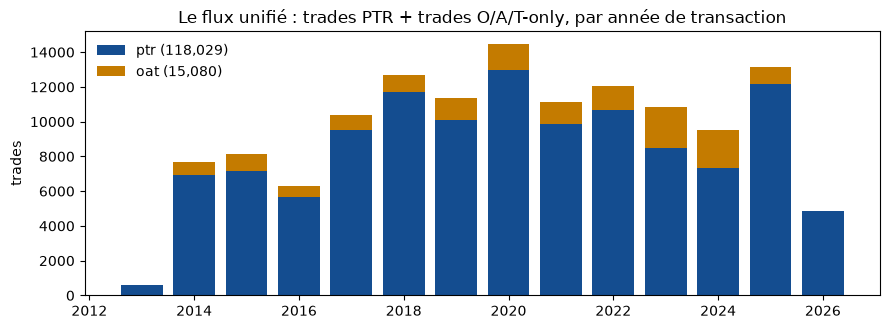

In [27]:
# FIGURE 1 — qui apporte quoi : trades par année, empilés ptr/oat
_ct = pd.crosstab(df_uni["traded"].dt.year, df_uni["provenance"])
_ct = _ct.loc[_ct.index >= 2013]
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(_ct.index, _ct["ptr"], color="#144d90", label=f"ptr ({_ct['ptr'].sum():,})")
ax.bar(_ct.index, _ct["oat"], bottom=_ct["ptr"], color="#c47b00", label=f"oat ({_ct['oat'].sum():,})")
ax.set_title("Le flux unifié : trades PTR + trades O/A/T-only, par année de transaction")
ax.set_ylabel("trades"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

In [28]:
# Qui sont les gros apporteurs d'oat ? (top 10, avec leur part)
_top = (df_uni.assign(n=1)
        .pivot_table(index=["bioguide_id", "name"], columns="provenance",
                     values="n", aggfunc="sum", fill_value=0)
        .assign(part_oat=lambda d: d["oat"] / (d["oat"] + d["ptr"]))
        .sort_values("oat", ascending=False))
display(_top.head(10).style.format({"part_oat": "{:.0%}"}))

,provenance,oat,ptr,part_oat
bioguide_id,name,,,
G000535,Luis V. Gutierrez,698,21,97%
G000583,Josh Gottheimer,455,3054,13%
M001135,Kathy Manning,453,729,38%
M001201,Paul Mitchell,427,2,100%
T000463,Michael R. Turner,347,2,99%
B001303,Lisa Blunt Rochester,300,0,100%
P000034,Frank Pallone,299,12,96%
S001206,Donna Shalala,268,445,38%
C001066,Kathy Castor,267,79,77%


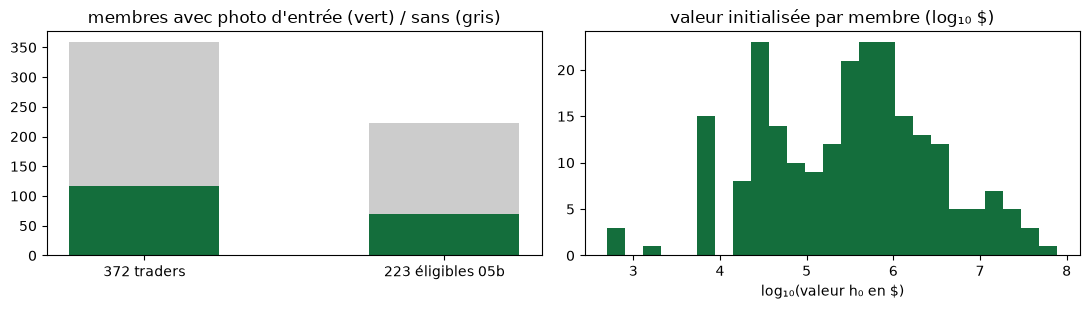

valeur h₀ médiane 387,505 $ · max 78,321,726 $ (G000599)


In [29]:
# FIGURE 2 — couverture du h₀ : qui a une photo, et pour combien
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
_bids_h0 = set(h0_parts["bioguide_id"])
axes[0].bar(["372 traders", "223 éligibles 05b"],
            [len(_bids_h0 & set(df["bioguide_id"])), len(_bids_h0 & set(_elig))],
            color="#146e3c", width=0.5)
axes[0].bar(["372 traders", "223 éligibles 05b"],
            [df["bioguide_id"].nunique() - len(_bids_h0 & set(df["bioguide_id"])),
             len(_elig) - len(_bids_h0 & set(_elig))],
            bottom=[len(_bids_h0 & set(df["bioguide_id"])), len(_bids_h0 & set(_elig))],
            color="#cccccc", width=0.5)
axes[0].set_title("membres avec photo d'entrée (vert) / sans (gris)")
_v0 = h0_parts.assign(v=lambda d: d["q0"] * 1.0).groupby("bioguide_id").apply(
    lambda d: (d["q0"] * np.array([prices_all[t].loc[t0] for t, t0 in zip(d["ticker"], d["t0"])])).sum(),
    include_groups=False)
axes[1].hist(np.log10(_v0.clip(lower=1)), bins=25, color="#146e3c")
axes[1].set_title("valeur initialisée par membre (log₁₀ $)")
axes[1].set_xlabel("log₁₀(valeur h₀ en $)")
plt.tight_layout(); plt.show()
print(f"valeur h₀ médiane {_v0.median():,.0f} $ · max {_v0.max():,.0f} $ ({_v0.idxmax()})")

### §2.3 Validation §2
q₀ > 0 et fini partout · F_oat sans collision exacte avec F_ptr · fenêtre et prix contrôlés ligne à ligne.

In [30]:
assert (h0_parts["q0"] > 0).all() and np.isfinite(h0_parts["q0"]).all()
assert df_uni["op"].isin(["buy", "sell"]).all()
assert df_uni["traded"].dt.year.between(2013, 2026).all()
assert df_uni["ticker"].isin(prices_all).all()
print("✅ §2 : h₀ et flux unifié valides")

✅ §2 : h₀ et flux unifié valides


## §3 — Le moteur, étendu — et les 4 runs

Mêmes règles que `member_shares` (05b) ; seul l'état initial change :

$$h(t) = \underbrace{q_0 \,\mathbb 1_{t \geq \tau(f_0)}}_{\text{photo d'entrée}}
 + \sum_{\text{achats} \leq t} q \; - \sum_{\text{ventes} \leq t} \min(q, h^-)$$

L'injection de q₀ est un **apport** : avec le rendement time-weighted (parts de la veille),
un apport ne crée jamais de performance. Ventes toujours sans short (min(q, h)).
On journalise la **masse tronquée** : Σ (q − min(q, h))·P à chaque vente.

In [31]:
def member_shares_v2(g, h0_rows=None):
    """member_shares du 05b + état initial optionnel. Retourne (N, tronque_usd)."""
    _h0 = ({r.ticker: (r.t0, r.q0) for r in h0_rows.itertuples()}
           if h0_rows is not None and len(h0_rows) else {})
    cols, tronque = {}, 0.0
    for tk in sorted(set(g["ticker"]) | set(_h0)):
        gt = g[g["ticker"] == tk]
        h, events = 0.0, {}
        rows = ([(pd.Timestamp(_h0[tk][0]), "h0", _h0[tk][1], None)] if tk in _h0 else [])
        rows += [(row["traded"], row["op"], None, row["size_usd"])
                 for _, row in gt.sort_values("traded").iterrows()]
        for d, op, q0, usd in sorted(rows, key=lambda x: (x[0], 0 if x[1] == "h0" else 1)):
            if op == "h0":
                events[d] = h = h + q0                      # d est déjà tau(f0), prix déjà consommé
                continue
            dd, p = eff_price_all(tk, d)
            if dd is None: continue
            qty = usd / p
            if op == "buy":
                h = h + qty
            else:
                tronque += (qty - min(qty, h)) * p
                h = h - min(qty, h)
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return (pd.DataFrame(cols) if cols else None), tronque

def daily_return_v2(N):
    """copie PARAMÉTRÉE de daily_return (05b cellule 14) : prices → prices_all, mêmes règles."""
    P = pd.DataFrame({tk: prices_all[tk] for tk in N.columns})
    Nsh = N.shift(1)
    num = (Nsh * P).sum(axis=1)
    den = (Nsh * P.shift(1)).sum(axis=1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index)
    r = r.clip(-0.5, 0.5)
    active = N.sum(axis=1) > 0
    if not active.any():
        return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]

**Les 4 runs.** Chacun = (flux, h₀) ; tout le reste est identique.

| run | flux | h₀ | rôle |
|---|---|---|---|
| A | ptr | non | témoin ≡ 05b (assert) |
| B | ptr | oui | effet du portefeuille d'entrée seul |
| C | ptr ∪ oat | non | effet des trades O/A/T seuls |
| D | ptr ∪ oat | oui | **la stratégie adaptée** |

In [32]:
def run_moteur(flux, use_h0):
    wfr, wft, tronq = {}, {}, {}
    _h0g = dict(tuple(h0_parts.groupby("bioguide_id"))) if use_h0 else {}
    _bids = sorted(set(flux["bioguide_id"]) | set(_h0g))
    _fg = dict(tuple(flux.groupby("bioguide_id")))
    for bid in _bids:
        g = _fg.get(bid, flux.iloc[0:0])
        N, tr = member_shares_v2(g, _h0g.get(bid))
        if N is None: continue
        r = daily_return_v2(N)
        if len(r) < 2 or r.std() == 0: continue
        wfr[bid], tronq[bid] = r, tr
        wft[bid] = pd.to_datetime(np.sort(g["traded"].values))
    return wfr, wft, tronq

F_ptr = df_uni[df_uni["provenance"] == "ptr"]
runA = run_moteur(F_ptr, use_h0=False)
print(f"run A : {len(runA[0])} membres")

run A : 266 membres


**Run A ≡ 05b, prouvé** : les 266 séries de `member_shares_v2` sans ajout doivent être
identiques à celles du moteur original (§1).

In [33]:
assert set(runA[0]) == set(wf_ret), "membres différents"
for _b in wf_ret:
    assert runA[0][_b].equals(wf_ret[_b]), f"série divergente : {_b}"
assert sum(runA[2].values()) > 0                     # la troncature existe déjà en P-only
print(f"✅ run A ≡ 05b : {len(wf_ret)} séries identiques | "
      f"masse tronquée P-only : {sum(runA[2].values())/1e6:,.0f} M$")

✅ run A ≡ 05b : 266 séries identiques | masse tronquée P-only : 1,205 M$


In [34]:
runB = run_moteur(F_ptr, use_h0=True)
print(f"run B (+h₀) : {len(runB[0])} membres | masse tronquée : {sum(runB[2].values())/1e6:,.0f} M$")

run B (+h₀) : 408 membres | masse tronquée : 1,166 M$


In [35]:
runC = run_moteur(df_uni, use_h0=False)
print(f"run C (+oat) : {len(runC[0])} membres | masse tronquée : {sum(runC[2].values())/1e6:,.0f} M$")

run C (+oat) : 404 membres | masse tronquée : 1,464 M$


In [36]:
runD = run_moteur(df_uni, use_h0=True)
print(f"run D (+h₀ +oat) : {len(runD[0])} membres | masse tronquée : {sum(runD[2].values())/1e6:,.0f} M$")

run D (+h₀ +oat) : 495 membres | masse tronquée : 1,406 M$


In [37]:
# Tableau récap des 4 runs (membres, éligibles à la règle du 05b, troncature)
RUNS = {"A (05b)": runA, "B (+h₀)": runB, "C (+oat)": runC, "D (adaptée)": runD}
def _elig_of(run):
    wfr, wft, _ = run
    return [b for b in wfr if len(wft[b]) >= MIN_TRADES and len(wfr[b]) >= MIN_DAYS]
recap3 = pd.DataFrame({k: dict(membres=len(r[0]), eligibles=len(_elig_of(r)),
                               tronque_MUSD=round(sum(r[2].values())/1e6))
                       for k, r in RUNS.items()}).T
display(recap3)

,membres,eligibles,tronque_MUSD
A (05b),266,223,1205
B (+h₀),408,230,1166
C (+oat),404,320,1464
D (adaptée),495,325,1406


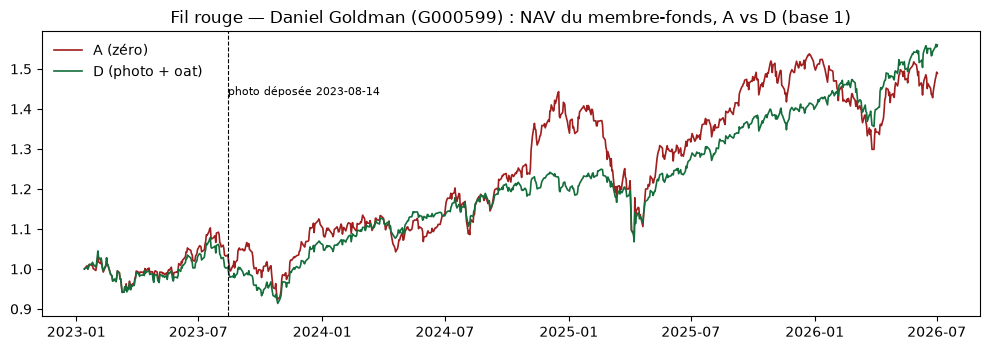

In [38]:
# FIGURE 3 — fil rouge : le membre à la plus grosse valeur initialisée parmi les éligibles
_fil = _v0.loc[_v0.index.isin(_elig)].idxmax()
_nom = df.loc[df["bioguide_id"] == _fil, "name"].iloc[0]
_f0 = h0_parts.loc[h0_parts["bioguide_id"] == _fil, "t0"].min()
fig, ax = plt.subplots(figsize=(10, 3.6))
for _lbl, _run, _c in [("A (zéro)", runA, "#a01e1e"), ("D (photo + oat)", runD, "#146e3c")]:
    _r = _run[0].get(_fil)
    if _r is None: continue
    ax.plot((1 + _r).cumprod(), label=_lbl, color=_c, lw=1.2)
ax.axvline(_f0, ls="--", c="k", lw=.8)
ax.annotate(f"photo déposée {pd.Timestamp(_f0).date()}", (_f0, ax.get_ylim()[1]*0.9), fontsize=8)
ax.set_title(f"Fil rouge — {_nom} ({_fil}) : NAV du membre-fonds, A vs D (base 1)")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

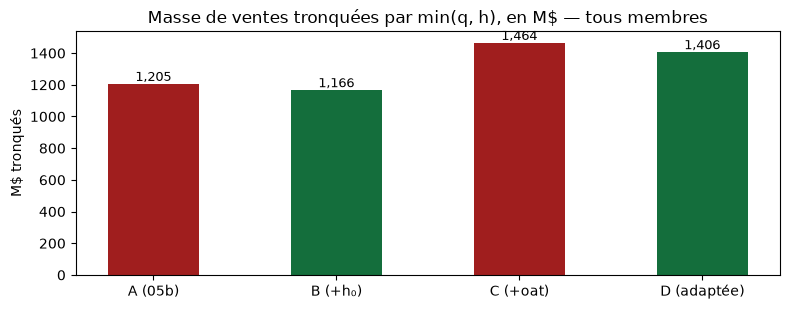

membres à photo seulement : 429 M$ (A) → 390 M$ (B)


In [39]:
# FIGURE 4 — la troncature des ventes fond quand h₀ existe
_t_by = pd.DataFrame({k: pd.Series(r[2]) for k, r in RUNS.items()}).fillna(0.0)
_sub = _t_by.loc[_t_by.index.isin(h0_parts["bioguide_id"].unique())]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(range(4), _t_by.sum() / 1e6, color=["#a01e1e", "#146e3c", "#a01e1e", "#146e3c"], width=0.5,
       tick_label=list(RUNS))
ax.set_title("Masse de ventes tronquées par min(q, h), en M$ — tous membres")
ax.set_ylabel("M$ tronqués")
for i, v in enumerate(_t_by.sum() / 1e6):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()
print(f"membres à photo seulement : {_sub['A (05b)'].sum()/1e6:,.0f} M$ (A) → {_sub['B (+h₀)'].sum()/1e6:,.0f} M$ (B)")

### §3.1 Validation §3
Run A bit-identique (fait ci-dessus) · B ne diffère de A que pour les membres à photo ·
parts jamais négatives (min(q,h) par construction).

In [40]:
_sans_photo = [b for b in wf_ret if b not in set(h0_parts["bioguide_id"])]
for _b in _sans_photo[:50]:
    assert runB[0][_b].equals(runA[0][_b])
print(f"✅ B ≡ A pour les membres sans photo (contrôle sur {min(50, len(_sans_photo))} membres)")

✅ B ≡ A pour les membres sans photo (contrôle sur 50 membres)


## §4 — La même stratégie, rejouée sur A / B / C / D

Règles du 05b, inchangées : classement point-in-time au 31/12/Y (IR vs SPY, gardé si t > 1,645 ;
variante appraisal), copie du **top-4 en parts** (poids 1/4, buy-and-hold un an, autofinancé).
Les fonctions ci-dessous sont la **copie paramétrée** des cellules 34/38/40 du 05b : mêmes règles,
l'état global (wf_ret, wf_traded, NAVK) devient argument.

In [41]:
# copie 05b cellule 40 (fonctions seules) — évaluation par années civiles
def yearly_excess(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    return pd.Series({y: ((1 + r[r.index.year == y]).prod() - 1) - ((1 + b[r.index.year == y]).prod() - 1)
                      for y in sorted(set(r.index.year))})

def eval_yearly(r):
    e = yearly_excess(r); n = len(e); ir_an = e.mean() / e.std(ddof=1)
    return dict(exces_moyen=e.mean(), IR_annuel=ir_an, t=ir_an * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}")

def _ligne(r):
    e = eval_yearly(r); a = alpha_beta(r)
    return dict(exces_an=e["exces_moyen"], t=e["t"], gagnantes=e["gagnantes"],
                beta=a["beta"], alpha_ann=a["alpha_ann"], t_appr=a["t_appr"])

In [42]:
# copie PARAMÉTRÉE 05b cellule 34 — classement point-in-time au 31/12/Y
def classement_a_fin_v2(Y, wfr, wft, noms, min_trades=MIN_TRADES, min_days=MIN_DAYS,
                        seuil_t=1.645, critere="ir"):
    yend = pd.Timestamp(f"{Y}-12-31")
    rows = []
    for bid, r in wfr.items():
        rr = r.loc[:yend]
        n_trades = int((wft[bid] <= yend).sum())
        n_days = len(rr)
        if n_days < 2 or rr.std() == 0 or n_trades < min_trades or n_days < min_days:
            continue
        if critere == "ir":
            x = (rr - r_spy.reindex(rr.index)).dropna()
            if len(x) < 2 or x.std() == 0: continue
            score = x.mean() / x.std() * np.sqrt(252); t = score * np.sqrt(n_days / 252)
        else:
            ab = alpha_beta(rr); score, t = ab["appraisal"], ab["t_appr"]
            if not np.isfinite(t): continue
        if t <= seuil_t: continue
        rows.append(dict(bioguide_id=bid, name=noms.get(bid, bid), n_trades=n_trades,
                         n_days=n_days, score=score, t=t))
    cols = ["bioguide_id", "name", "n_trades", "n_days", "score", "t"]
    return (pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=cols))

In [43]:
# copie PARAMÉTRÉE 05b cellule 38 — le moteur en parts (top-K, cadence annuelle)
def strategie_en_parts_v2(K, wfr, wft, noms, critere="ir"):
    navk = pd.DataFrame({bid: (1 + r.reindex(cal).fillna(0.0)).cumprod() for bid, r in wfr.items()})
    clsm = {Y: classement_a_fin_v2(Y, wfr, wft, noms, critere=critere) for Y in range(2014, 2027)}
    W, rets, journal = 100.0, [], []
    for Y in range(2015, 2026):
        c = clsm[Y]
        sel = list(zip(c["score"].head(K), c["bioguide_id"].head(K)))
        idx = cal[cal.year == (Y + 1)]
        if not sel or not len(idx): continue
        bids = [b for _, b in sel]; w = np.ones(len(bids)) / len(bids)
        tR = cal[cal.get_loc(idx[0]) - 1]
        nbr = pd.Series(w * W / navk.loc[tR, bids].values, index=bids)
        nav = navk.loc[idx, bids].mul(nbr, axis=1).sum(axis=1)
        r = nav / nav.shift(1) - 1
        r.iloc[0] = nav.iloc[0] / W - 1
        journal.append(dict(annee=Y + 1, bids=bids))
        W = float(nav.iloc[-1]); rets.append(r)
    return dict(r=pd.concat(rets).sort_index(), journal=journal, clsm=clsm)

In [44]:
# La stratégie top-4 (sélection IR) sur les 4 runs — le tableau central du notebook
NOMS = dict(df_uni.drop_duplicates("bioguide_id")[["bioguide_id", "name"]].values)
strat = {k: strategie_en_parts_v2(4, r[0], r[1], NOMS, critere="ir") for k, r in RUNS.items()}
tab4 = pd.DataFrame({k: _ligne(s["r"]) for k, s in strat.items()}).T
print(f"top-4, poids 1/4, rebalancement annuel, sélection IR (t > 1,645) — "
      f"{len(yearly_excess(strat['A (05b)']['r']))} années civiles, seuil t₁₀ ≈ 1,81")
display(tab4.round(3))

top-4, poids 1/4, rebalancement annuel, sélection IR (t > 1,645) — 11 années civiles, seuil t₁₀ ≈ 1,81


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
A (05b),0.031021,0.943191,7/11,1.198154,-0.004367,-0.127805
B (+h₀),0.036661,0.849977,7/11,1.223547,-0.009954,-0.23628
C (+oat),0.017469,0.549585,6/11,1.13645,-0.011813,-0.461391
D (adaptée),0.02481,1.139788,7/11,1.100349,0.007969,0.267936


**Oracle** : le run A doit redonner les chiffres publiés du 05b (excès +3,1 %/an, t = 0,943, β = 1,198).

In [45]:
_a = tab4.loc["A (05b)"]
assert abs(_a["exces_an"] - 0.031021) < 1e-4 and abs(_a["t"] - 0.943191) < 1e-3 \
       and abs(_a["beta"] - 1.198154) < 1e-4
print("✅ stratégie run A ≡ chiffres du 05b (B5)")

✅ stratégie run A ≡ chiffres du 05b (B5)


In [46]:
# Variante : sélection appraisal (2e critère du 05b), mêmes runs
tab4b = pd.DataFrame({k: _ligne(strategie_en_parts_v2(4, r[0], r[1], NOMS, critere="appraisal")["r"])
                      for k, r in RUNS.items()}).T
display(tab4b.round(3))

,exces_an,t,gagnantes,beta,alpha_ann,t_appr
A (05b),-0.025215,-1.24163,3/11,1.009716,-0.022867,-0.754999
B (+h₀),-0.010729,-0.388644,4/11,1.0057,-0.013082,-0.369676
C (+oat),-0.00267,-0.12798,5/11,0.982287,0.00055,0.01893
D (adaptée),0.001623,0.087653,6/11,0.976568,0.003606,0.13095


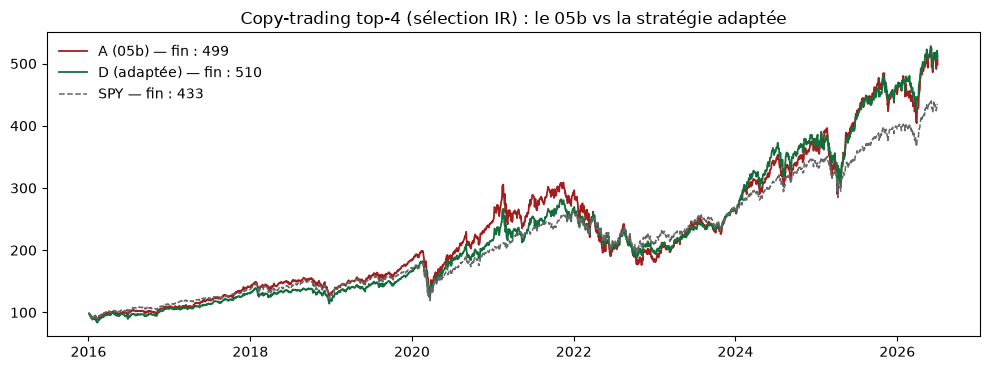

In [47]:
# FIGURE 5 — NAV du top-4 (sélection IR) : A vs D vs SPY, base 100 au 1er jour commun
_rA, _rD = strat["A (05b)"]["r"], strat["D (adaptée)"]["r"]
_i0 = max(_rA.index[0], _rD.index[0])
fig, ax = plt.subplots(figsize=(10, 3.8))
for _lbl, _r, _c in [("A (05b)", _rA, "#a01e1e"), ("D (adaptée)", _rD, "#146e3c")]:
    _n = (1 + _r[_r.index >= _i0]).cumprod() * 100
    ax.plot(_n, label=f"{_lbl} — fin : {_n.iloc[-1]:,.0f}", color=_c, lw=1.3)
_spy = (1 + r_spy[r_spy.index >= _i0].fillna(0)).cumprod() * 100
ax.plot(_spy, label=f"SPY — fin : {_spy.iloc[-1]:,.0f}", color="#666666", lw=1.1, ls="--")
ax.set_title("Copy-trading top-4 (sélection IR) : le 05b vs la stratégie adaptée")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

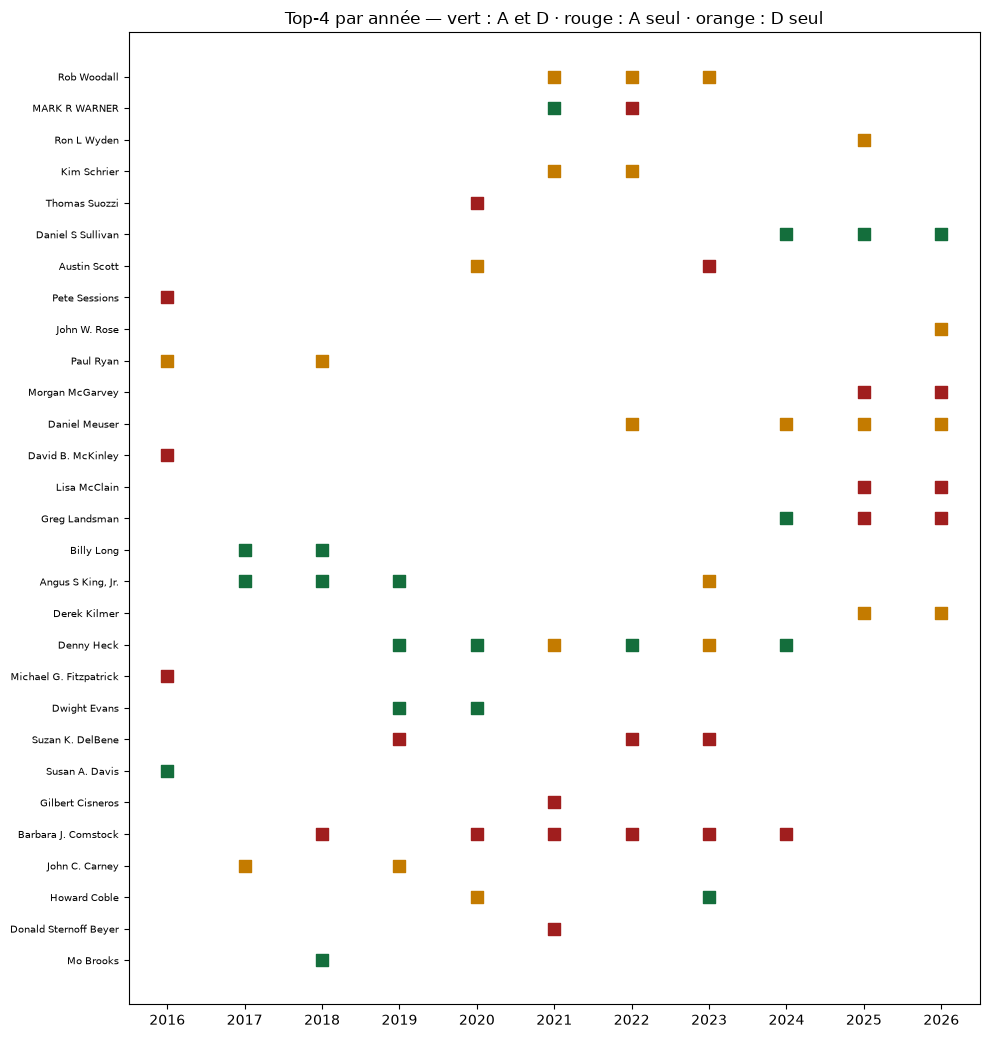

coupes où la sélection change entre A et D : 11/11


In [48]:
# FIGURE 6 — qui est copié ? composition du top-4 par année, A vs D
_ans = [j["annee"] for j in strat["A (05b)"]["journal"]]
_selA = {j["annee"]: j["bids"] for j in strat["A (05b)"]["journal"]}
_selD = {j["annee"]: j["bids"] for j in strat["D (adaptée)"]["journal"]}
_tous = sorted({b for s in list(_selA.values()) + list(_selD.values()) for b in s})
fig, ax = plt.subplots(figsize=(10, 0.32 * len(_tous) + 1.2))
for yi, b in enumerate(_tous):
    for xi, an in enumerate(_ans):
        inA, inD = b in _selA.get(an, []), b in _selD.get(an, [])
        c = "#146e3c" if (inA and inD) else ("#a01e1e" if inA else ("#c47b00" if inD else None))
        if c:
            ax.scatter(xi, yi, s=70, marker="s", color=c)
ax.set_xticks(range(len(_ans))); ax.set_xticklabels(_ans)
ax.set_yticks(range(len(_tous))); ax.set_yticklabels([NOMS.get(b, b) for b in _tous], fontsize=7)
ax.set_title("Top-4 par année — vert : A et D · rouge : A seul · orange : D seul")
plt.tight_layout(); plt.show()
_ch = sum(set(_selA.get(a, [])) != set(_selD.get(a, [])) for a in _ans)
print(f"coupes où la sélection change entre A et D : {_ch}/{len(_ans)}")

## §5 — Lecture

In [49]:
_dA, _dD = tab4.loc["A (05b)"], tab4.loc["D (adaptée)"]
print("Synthèse chiffrée (top-4, sélection IR) :")
print(f"  excès/an  : {_dA['exces_an']*100:+.1f} % (A) → {_dD['exces_an']*100:+.1f} % (D)")
print(f"  t         : {_dA['t']:.2f} (A) → {_dD['t']:.2f} (D)   — seuil t₁₀ ≈ 1,81")
print(f"  β         : {_dA['beta']:.2f} (A) → {_dD['beta']:.2f} (D)")
print(f"  α (appr.) : t = {_dA['t_appr']:.2f} (A) → {_dD['t_appr']:.2f} (D)")
print(f"  éligibles : {recap3.loc['A (05b)', 'eligibles']} (A) → {recap3.loc['D (adaptée)', 'eligibles']} (D)")
print(f"  troncature: {recap3.loc['A (05b)', 'tronque_MUSD']:,} M$ (A) → {recap3.loc['D (adaptée)', 'tronque_MUSD']:,} M$ (D)")

Synthèse chiffrée (top-4, sélection IR) :
  excès/an  : +3.1 % (A) → +2.5 % (D)
  t         : 0.94 (A) → 1.14 (D)   — seuil t₁₀ ≈ 1,81
  β         : 1.20 (A) → 1.10 (D)
  α (appr.) : t = -0.13 (A) → 0.27 (D)
  éligibles : 223 (A) → 325 (D)
  troncature: 1,205 M$ (A) → 1,406 M$ (D)


**À retenir (structurel, indépendant des chiffres ci-dessus)** :
- les trades O/A/T entrent à leur **date de transaction**, comme tout le 05b — c'est la convention
  du moteur (ils sont divulgués ~374 j après : même caveat que le look-ahead léger assumé du 05b) ;
- **122/372** membres ont une photo d'entrée (73/223 éligibles) — les autres démarrent de zéro,
  comme avant : c'est la donnée, pas un choix ;
- l'injection h₀ est un apport au 1er jour coté ≥ **date de dépôt** de la photo — jamais avant ;
- un achat PTR antérieur au dépôt de la photo peut être compté deux fois (dans h₀ et dans le flux) :
  non réconciliable en fourchettes, assumé et documenté ;
- la valeur des photos convertie en parts est bornée par la couverture prix (§2.1) — le non-coté
  (fonds, LLC, immobilier) reste dehors, comme dans tout le projet.

In [50]:
# Garde-fou final : prices_v2 n'a pas bougé
assert sorted(os.listdir(PRICES_V2)) == _SNAP_PV2, "prices_v2 modifié — INTERDIT"
print(f"✅ prices_v2 intact ({len(_SNAP_PV2)} fichiers) — oracles du 05b/07/09 préservés")

✅ prices_v2 intact (3351 fichiers) — oracles du 05b/07/09 préservés
